In [83]:
import astropy
import healpy as hp
import matplotlib.pyplot as plt 
import numpy as np
import shutil
from astropy.io import fits
import xml.dom.minidom
from astropy import units as u
from astropy.coordinates import SkyCoord
from healpy.newvisufunc import projview
from source_generation.agn_spectral_parameters import energy_flux_agn
from source_generation.pulsar_spectral_parameters import energy_flux_pulsar
import copy


In [84]:
def format_scientific_notation_label(numbers):
    
    # Formats numbers into scientific notation for inclusion on graphs
    
    labels = []
    
    for number in numbers:
        
        scientific = str(np.format_float_scientific(number, precision=2, trim='0'))
        
        base, exponent = scientific.split('e')
        
        if exponent[0] == "+":
            sign=""
        else:
            sign="-"
            
        label = base + "$\\times 10^{" + sign + str(int(exponent[1:])) + "}$"
        
        labels.append(label)
        
    return labels

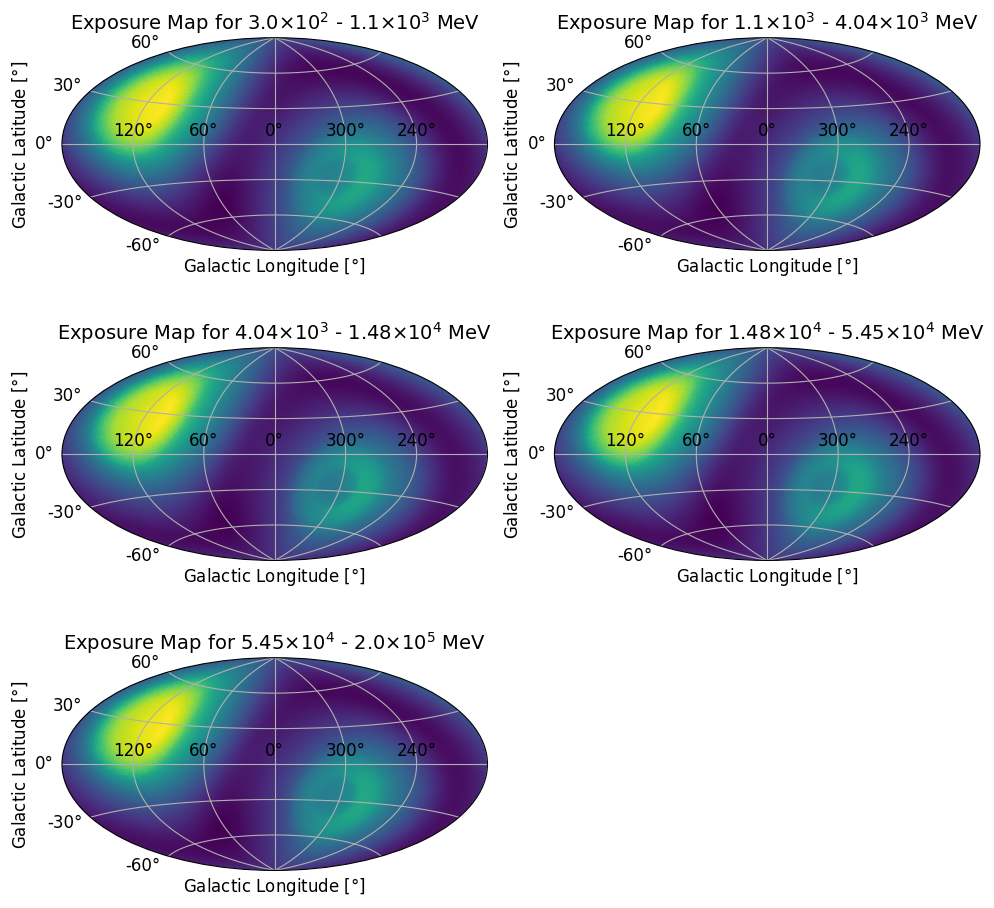

In [85]:
# Read and plot binned exposure files - get valuable variables as well (including nside)

exposure_file = "/Volumes/T7/project_data/real_data/fermi_filtered_gti_exposure_map.fits"

with fits.open(exposure_file) as hdul:
    
    num_bins = hdul[1].header["TFIELDS"]
    
    energy_bins = np.array([k[0] for k in hdul[2].data])
    
    energy_bin_labels = format_scientific_notation_label(energy_bins)
    
    for b in range(num_bins - 1):
        
        # Read in exposure map
        healpix_exposure_map = hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=b)
            
        nside = hp.pixelfunc.get_nside(healpix_exposure_map)
        
        # New plot function - this is experimental, but the following sections will not be effected if there are some minor bugs
        
        projview(
        healpix_exposure_map,
        coord=["G"],
        graticule=True,
        graticule_labels=True,
        xlabel="Galactic Longitude [$\degree$]",
        ylabel="Galactic Latitude [$\degree$]",
        cb_orientation="vertical",
        projection_type="aitoff",
        title="Exposure Map for {} - {} MeV".format(energy_bin_labels[b], energy_bin_labels[b + 1]),
        cbar=False,
        sub=(3, 2, b + 1),
        )
        
    plt.tight_layout()
        
    plt.show()
    
    plt.close()


In [86]:
# Read XML files to get latitude and longitude of each source (separate into AGN, pulsars, and background)

xml_file = "./simulated_data/sources.xml"

docs = xml.dom.minidom.parse(xml_file)

sources = docs.getElementsByTagName("source")

spatial_models = []

coordinates = []
fluxes = []

# Lowest energy to highest energy of events
min_energy = energy_bins[0]
max_energy = energy_bins[-1]

# Parse XML
for source in sources:
    
    source_type = source.getAttribute("name")[:3]
    source_category = source.getAttribute("type")
    
    if source_category == "DiffuseSource":
        # Skip background/diffuse sources (if present) - we focus on point sources here
        continue
        
    else:
        
        # PARSE SPATIAL PARAMETERS 
        
        spatial_model = source.getElementsByTagName("spatialModel")[0]
            
        parameters = spatial_model.getElementsByTagName("parameter")
    
        coordinate = [0, 0]
        
        for param in parameters:
            name = param.getAttribute("name")
            
            if name == "RA":
                coordinate[0] = float(param.getAttribute("value"))
            else:
                coordinate[1] = float(param.getAttribute("value"))
        
        coordinates.append(coordinate)
        
        # PARSE SPECTRAL FEATURES AND CALCULATE FLUX
        
        spectral_model = source.getElementsByTagName("spectrum")[0]
        
        spectral_parameter_dictionary = dict()
        
        # Get spectral parameters
        
        parameters = spectral_model.getElementsByTagName("parameter")
        
        for param in parameters:
            
            name = param.getAttribute("name")
            
            scale = float(param.getAttribute("scale"))
            
            value = float(param.getAttribute("value"))
            
            actual_value = scale * value
                
            spectral_parameter_dictionary[name] = actual_value
        
        binned_fluxes = []
        
        if source_type == "AGN":
            
            # Parse spectral parameters
            
            # For each energy interval, calculate corresponding flux
            for f in range(num_bins - 1):
            
                # flux = energy_flux_agn(pivot_energy=spectral_parameter_dictionary["Eb"], flux_density=spectral_parameter_dictionary["norm"], spectral_slope=spectral_parameter_dictionary["alpha"], curvature=spectral_parameter_dictionary["beta"], min_energy=min_energy, max_energy=max_energy)
            
                flux = energy_flux_agn(pivot_energy=spectral_parameter_dictionary["Eb"], flux_density=spectral_parameter_dictionary["norm"], spectral_slope=spectral_parameter_dictionary["alpha"], curvature=spectral_parameter_dictionary["beta"], min_energy=energy_bins[f], max_energy=energy_bins[f + 1])
                
                binned_fluxes.append(flux)
            
        elif source_type == "PSR":
            
            # For each energy interval, calculate corresponding flux
            for f in range(num_bins - 1):
            
                # flux = energy_flux_pulsar(pivot_energy=spectral_parameter_dictionary["Scale"], flux_density=spectral_parameter_dictionary["Prefactor"], spectral_slope=spectral_parameter_dictionary["Index1"], exponential_index=spectral_parameter_dictionary["Index2"], exponential_factor=spectral_parameter_dictionary["Expfactor"], min_energy=min_energy, max_energy=max_energy)
 
                flux = energy_flux_pulsar(pivot_energy=spectral_parameter_dictionary["Scale"], flux_density=spectral_parameter_dictionary["Prefactor"], spectral_slope=spectral_parameter_dictionary["Index1"], exponential_index=spectral_parameter_dictionary["Index2"], exponential_factor=spectral_parameter_dictionary["Expfactor"], min_energy=energy_bins[f], max_energy=energy_bins[f + 1]) 
            
                binned_fluxes.append(flux)
 
        else:
            
            # Unrecognised point source type - allows for debugging when adding in new source types to simulation
            raise TypeError("Cannot recognise source type {}".format(source_type))
    
        fluxes.append(binned_fluxes)
    
# Have coordinates in format [RA, DEC] - need to convert them to Lat-lon

# print(coordinates[0])

coordinates = [SkyCoord(ra=c[0]*u.degree, dec=c[1]*u.degree, frame='icrs').galactic for c in coordinates]

# print(coordinates[0])

# Get coordinates into numpy array then separate into list of lats and lons
coordinates = np.array([[c.l.value, c.b.value] for c in coordinates]).T

latitudes = coordinates[0]
longitudes = coordinates[1]

# pixels = hp.pixelfunc.ang2pix(nside=nside, theta=latitudes, phi=longitudes, lonlat=True)
pixels = hp.pixelfunc.ang2pix(nside=nside, theta=latitudes, phi=longitudes, lonlat=True)


/var/folders/kk/y42pmgj57vnc6d99z79kr8rm0000gn/T/ipykernel_85858/3603181045.py:29: RuntimeWarning: divide by zero encountered in log
  np.log(infinite_statistics_counts),


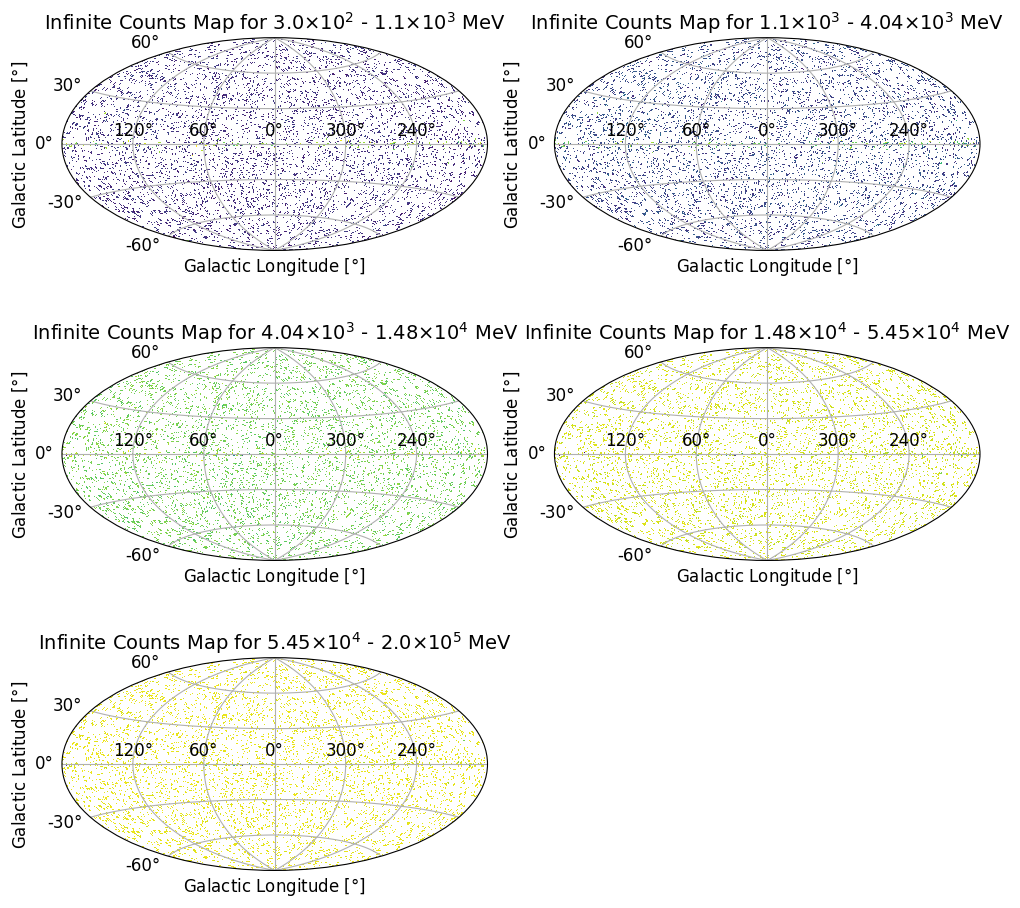

In [89]:
# We now have the source locations in lon-lat, the pixels in which they are situated in the healpix map, the binned exposure maps of the sky, and their fluxes

# convert fluxes to numpy format
fluxes = np.array(fluxes)

binned_infinite_statistics = []

for b in range(num_bins - 1):
    
    # Read in exposure map
    healpix_exposure_map = hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=b)
    
    # Copy for infinite statistics    
    infinite_statistics_counts = np.zeros_like(healpix_exposure_map)

    # Calculate infinite statistics realisation of sky (c bar)
    for x in range(len(latitudes)):
        
        pixel = pixels[x]
        
        # Important to add - Poisson value is additive
        infinite_statistics_counts[pixel] += healpix_exposure_map[pixel] * fluxes[x, b]
    
    # Add infinite statistics bin to list
    binned_infinite_statistics.append(infinite_statistics_counts)
     
    # Plot - for verification - N.B. I am plotting the logarithm here!
    projview(
    np.log(infinite_statistics_counts),
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    xlabel="Galactic Longitude [$\degree$]",
    ylabel="Galactic Latitude [$\degree$]",
    cb_orientation="vertical",
    projection_type="aitoff",
    title="Infinite Counts Map for {} - {} MeV".format(energy_bin_labels[b], energy_bin_labels[b + 1]),
    cbar=False,
    sub=(3, 2, b + 1),
    )
            
plt.tight_layout()

plt.show()

plt.close()
    

Number of Sources: 6189
Total Sources with Significant Energies: 
95


/var/folders/kk/y42pmgj57vnc6d99z79kr8rm0000gn/T/ipykernel_85858/2530802218.py:20: RuntimeWarning: divide by zero encountered in log
  np.log(sampled_counts),


Total Sources with Significant Energies: 
50
Total Sources with Significant Energies: 
35
Total Sources with Significant Energies: 
1085
Total Sources with Significant Energies: 
4408


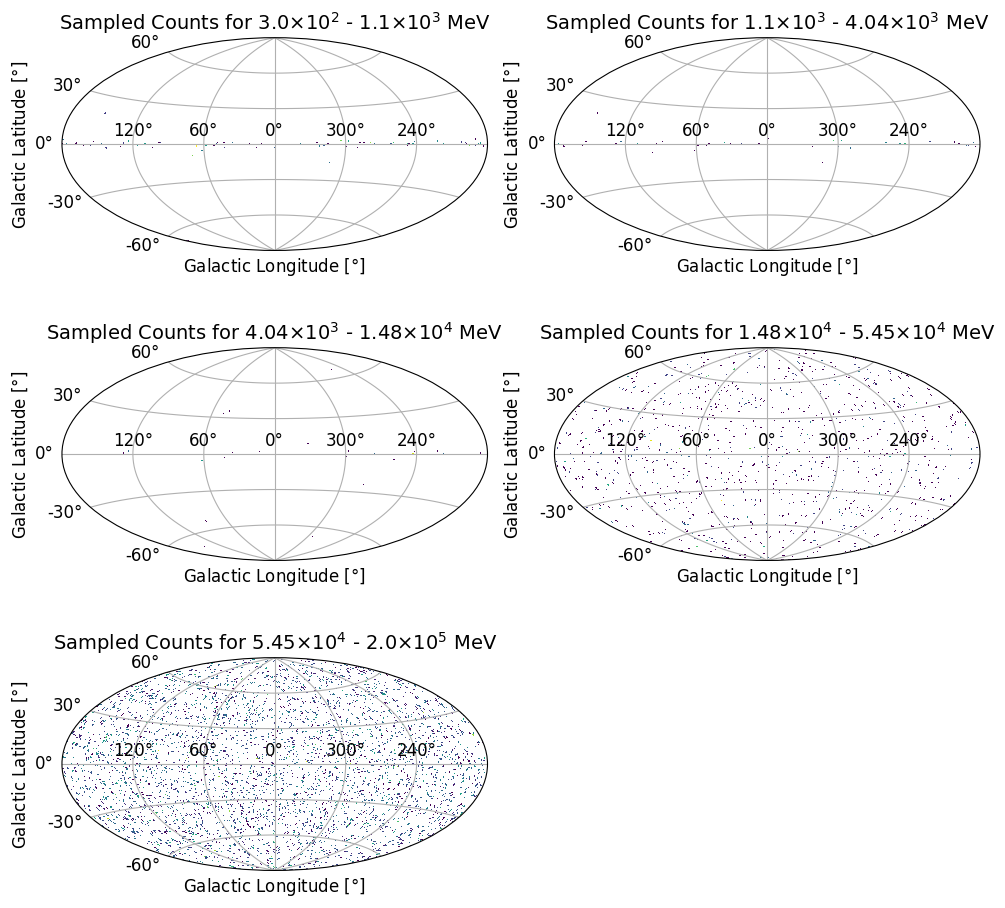

In [95]:
# Get count map - this is what ID8 used, but they did not convolve it with a PSF

binned_count_maps = []

print("Number of Sources: {}".format(len(latitudes)))

for b in range(num_bins - 1):
    
    # Poisson sample each pixel in the infinite statistics count map to get a count map c
    sampled_counts = np.random.poisson(lam=binned_infinite_statistics[b])
    
    binned_count_maps.append(sampled_counts)
    
    print("Total Sources with Significant Energies: ")
    print(np.sum(sampled_counts > 0))
    
    
    
    projview(
    np.log(sampled_counts),
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    xlabel="Galactic Longitude [$\degree$]",
    ylabel="Galactic Latitude [$\degree$]",
    cb_orientation="vertical",
    projection_type="aitoff",
    title="Sampled Counts for {} - {} MeV".format(energy_bin_labels[b], energy_bin_labels[b + 1]),
    cbar=False,
    sub=(3, 2, b + 1),
    )
    
plt.tight_layout()

plt.show()

plt.close()


0.014147522729054587
0.022447548354793977
0.03729014053721904
0.03816829061802251
0.042247575874967275


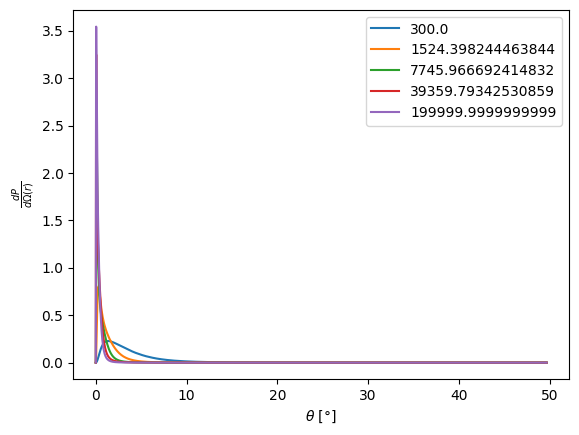

In [235]:
exposure_file = "/Volumes/T7/project_data/real_data/pointsource_psf.fits"

# GET PSF

# Parameters - see PSF diagram - figure 2 in robust neural papers

psf_values_energy_binned = []

with fits.open(exposure_file) as hdul:

    thetas = np.array([k[0] for k in hdul["THETA"].data])
    
    num_bins = len(hdul["PSF"].data)
    
    for b in range(num_bins):
        
        # Lowest energy (MeV) of this bin
        energy_value = hdul["PSF"].data[b][0]
        
        # Exposure value at that point
        tmp = hdul["PSF"].data[b][1]
        
        # PSF values dP/dOmega - probability to find event in solid angle dOmega at offset r from point source
        psf_values = np.array(hdul["PSF"].data[b][2])
        
        psf_values_energy_binned.append(psf_values)
        
        # Normalise to get probs
        # probs = psf_values * 2 * np.pi * thetas * 2 * np.pi * thetas
        
        # Normalise        
        # probs = ((2 * np.pi * thetas) ** 2) * psf_values
        
        psf_values /= np.max(psf_values)
        
        probs = ((2 * np.pi * thetas) ** 2) * psf_values
        
        # Integrate over probs to check that sum to 1
        diff = thetas[1] - thetas[0]
                
        approx_integral = np.sum(np.array([((probs[k + 1] + probs[k])/2) * (thetas[k + 1] - thetas[k]) for k in range(len(probs) - 1)]))
        
        # Normalise such that the integral is 1
        probs *= (1/approx_integral)
        
        # print(np.max(np.array([((probs[k + 1] + probs[k])/2) * (thetas[k + 1] - thetas[k]) for k in range(len(probs) - 1)])))
        
        plt.plot(thetas, probs, label="{}".format(energy_value))
                
        plt.xlabel("$\\theta\ [\degree]$")
        plt.ylabel("$\\frac{dP}{d\Omega(r)}$")
        
        plt.legend()

psf_values_energy_binned = np.array(psf_values_energy_binned)



1710.8939
855.0
0.003490658503988659


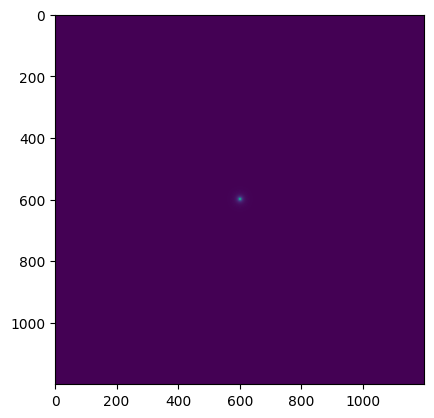

In [98]:
# Creating PSF for diffuse sources

roi_count_map = "/Volumes/T7/project_data/real_data/diffuse_psf_roi/count_map.fits"

with fits.open(roi_count_map) as hdul:

    counts = hdul[0].data
    
    plt.imshow(counts)
    
    midpoint = counts.shape[0] // 2
    
    x_axis = counts[midpoint]
    y_axis = counts[:, midpoint]
    
    values = (x_axis + y_axis) / 2
    
    max_value = np.max(values)
    
    print(max_value)
    print(max_value // 2)
    
    # Closest value to half the intensity - https://stackoverflow.com/questions/8914491/finding-the-nearest-value-and-return-the-index-of-array-in-python    
    half_intensity = (np.abs(values - (max_value // 2) )).argmin()
    
    # Find the difference between half way along the axis and centre - 0.05 degrees represented by 1 pixel. Multiply by two as it goes across the mean
    degrees_difference = np.abs(midpoint - half_intensity) * 0.05 * 2
    
    # Convert to radians
    degrees_difference *= (np.pi / 180)
    
    print(degrees_difference)












Filename: /Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      41   ()      
  1  HPXEXPOSURES    1 BinTableHDU     37   49152R x 7C   [D, D, D, D, D, D, D]   
  2  ENERGIES      1 BinTableHDU     13   7R x 1C   [1D]   
  3  GTI           1 BinTableHDU     18   98735R x 2C   [D, D]   
None
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   56 / width of table in bytes                        NAXIS2  =                49152 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    7 

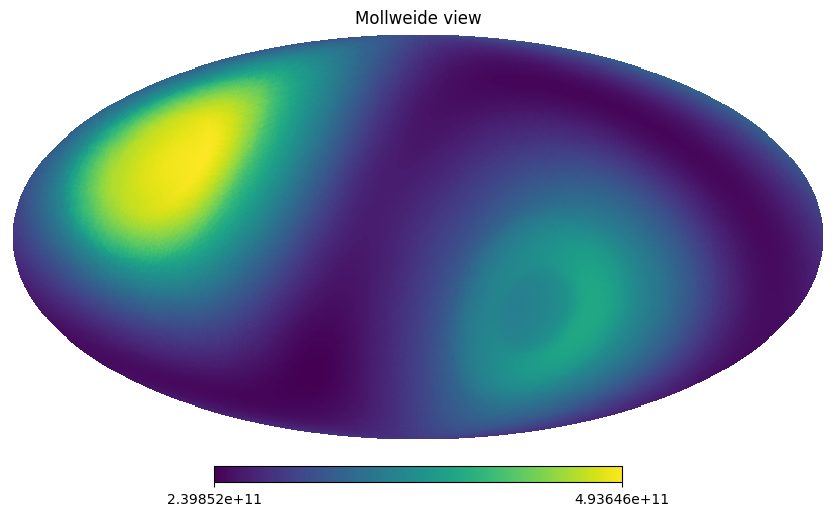

In [62]:
# Get number of bins

exposure_file = "/Volumes/T7/project_data/real_data/fermi_filtered_gti_exposure_map.fits"

with fits.open("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits") as hdul:
    
    print(hdul.info())
    
    print(hdul[1].header)
    
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES"))
    
with fits.open(exposure_file) as hdul:
    
    binned_map_data = hdul[0].data
    num_bins = binned_map_data.shape[0]
    energy_bin_boundaries = binned_map_data[1].data
    
    # exposure_map_1, header = hp.fitsfunc.read_map(exposure_file, h=True, hdu=1, field=(2))
    # 
    # print(hdul[0].header)
    
    # 
    # hp.mollview(exposure_map_1, title='Original Fits Plot')
    
for k in range(num_bins - 1):
    
    new_file = "/Volumes/T7/project_data/real_data/fermi_exposure_map_bin_{}.fits".format(k)
    
    shutil.copyfile(exposure_file, new_file)
            
    # Create separate binned data files
    with fits.open(new_file, mode='update') as hdul:
        
        binned_map_data = hdul[0].data
        
        healpix_map = binned_map_data[k]
        
        hdul[0].data = hdul[0].data[k]
                
        hdul.flush()


AttributeError: 'numpy.ndarray' object has no attribute 'field'

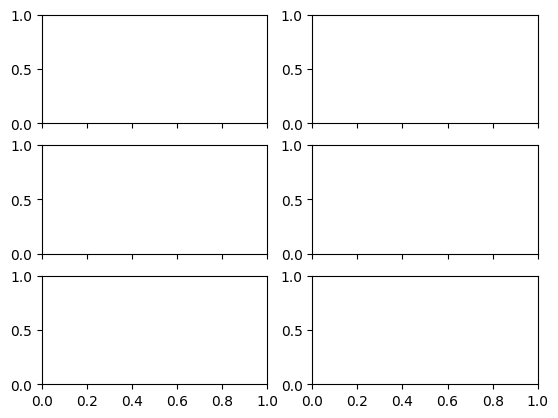

In [41]:
images = []

fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True)

# exposure_map_1 = hp.fitsfunc.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exposure_map_bin_0.fits", hdu=1, nest=False)
for k in range(num_bins - 1):
    
    file_name = "/Volumes/T7/project_data/real_data/fermi_exposure_map_bin_{}.fits".format(k)
    
    exposure_map_1 = hp.fitsfunc.read_map(file_name, hdu=0, nest=False)
    # 
    # hp.mollview(exposure_map_1, title='Original Fits Plot')
    
    with fits.open(file_name, mode='update') as hdul:
        
        i = k // 2
        j = k % 2
        
        data = hdul[0].data
        
        print(hdul[0].header)
        
        energy_bin_boundaries = np.array([k[0] for k in np.array(hdul[1].data)])
                
        images.append(data)
                
    ax[i][j].imshow(data, cmap='gray')
    
    ax[i, j].set_title("{} to {} MeV".format(np.round(energy_bin_boundaries[k], 2), np.round(energy_bin_boundaries[k + 1], 2)))
    
fig.suptitle("Exposure Maps")

ax = np.ravel(ax)

for a in ax:
    a.set_axis_off()

fig.tight_layout()

plt.show()

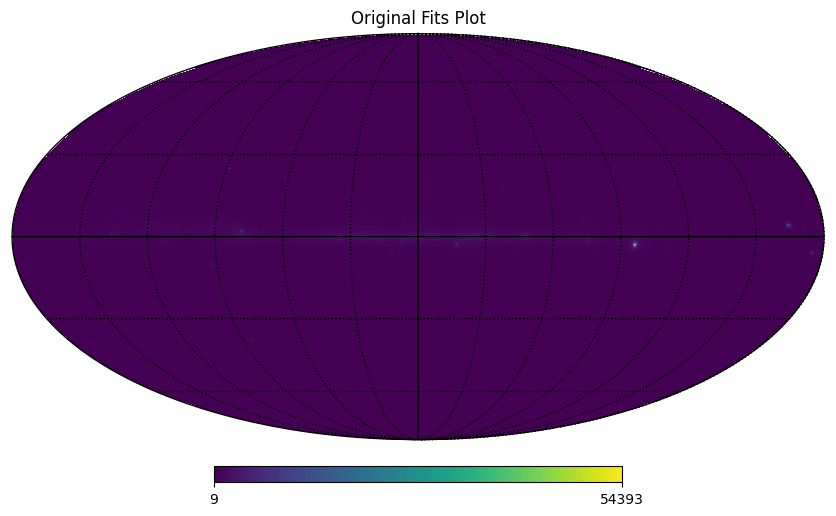

In [17]:
# hp.mollview(exposure_map, title='Original Fits Plot')
# hp.graticule()

In [ ]:
# REFERENCES

# Astropy Documentation - https://docs.astropy.org/en/stable/coordinates/skycoord.html